# Further Performance Metrics (original non-sampling dataset)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
X_train = pd.read_csv("/content/drive/My Drive/Colab Notebooks/data/X_train_final_ori.csv")
X_test = pd.read_csv("/content/drive/My Drive/Colab Notebooks/data/X_test_final.csv")
X_val = pd.read_csv("/content/drive/My Drive/Colab Notebooks/data/X_val_final.csv")

y_train = pd.read_csv("/content/drive/My Drive/Colab Notebooks/data/y_train_final_ori.csv")
y_test = pd.read_csv("/content/drive/My Drive/Colab Notebooks/data/y_test_final.csv")
y_val = pd.read_csv("/content/drive/My Drive/Colab Notebooks/data/y_val_final.csv")

## 5 Combinations of Features

In [3]:
feature_sets = {
    # "set_all": X_train.columns.tolist(),

    "set_1": [
        "sact",
        "physio1",
        "safety5",
        "belonging1",
        "esteem3",
        "trust3",
        "ethical80",
        "civic53",
        "compassion1",
        "compassion2",
        "compassion3",
        "compassion4",
        "growth16",
        "age",
        "marital_status",
        "religious1",
        "income_scale"
    ],

    "set_2": [
        "sact",
        "physio1",
        "safety5",
        "belonging1",
        "esteem3",
        "trust3",
        "ethical80",
        "civic53",
        "compassion2",
        "compassion3",
        "growth16",
        "age",
        "marital_status"
    ],

    "set_3": [ # maslow needs only
        "sact",
        "physio1",
        "safety5",
        "belonging1",
        "esteem3"
    ],

    "set_4": [ # maturity of heart only
        "trust3",
        "ethical80",
        "civic53",
        "compassion1",
        "compassion2",
        "growth16"
    ],

    "set_5": [ # hybrid
        "sact",
        "physio1",
        "safety5",
        "trust3",
        "ethical80"
    ],

    "set_6": [ # hybrid top 4
        "sact",
        "physio1",
        "safety5",
        "trust3"
    ],

    "set_7": [ # top 3
        "sact",
        "physio1",
        "safety5"
    ]
}



Create data splits.

In [4]:
data_splits = {}

for name, features in feature_sets.items():
    data_splits[name] = {
        "X_train": X_train[features],
        "X_val": X_val[features],
        "X_test": X_test[features],
        "feature_columns": features
    }

In [5]:
!pip install catboost

In [6]:
import warnings
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)

In [7]:
models = [
    {
        "name": "RandomForest",
        "estimator": RandomForestClassifier(random_state=42)
    },
    {
        "name": "CatBoost",
        "estimator": CatBoostClassifier(random_state=42, verbose=0),
        "param_grid": {
            "iterations": [100, 200],
            "learning_rate": [0.01, 0.05, 0.1],
            "depth": [3, 5, 7]
        }
    },
    {
        "name": "LogisticRegression",
        "estimator": LogisticRegression(random_state=42, max_iter=3000)
    },
    {
        "name": "NaiveBayes",
        "estimator": GaussianNB()
    }
]


## Model Training

In [8]:
import sys
sys.path.append('/content/drive/My Drive/Colab Notebooks/')
import my_tools

all_results = {}
all_models = {}

for combo_name, data in data_splits.items():
    print(f"\n==============================")
    print(f"Running feature set: {combo_name}")
    print(f"==============================")

    results_df, best_models =  my_tools.train_ensemble_models(
        data["X_train"], y_train,
        data["X_val"], y_val,
        data["X_test"], y_test,
        models,
        sort_by= "Test Accuracy"
    )

    # print(data["X_train"].columns.tolist())

    all_results[combo_name] = results_df
    all_models[combo_name] = best_models


Running feature set: set_1
y_train: Converted to 1D pd automatically...
y_test: Converted to 1D pd automatically...
y_val: Converted to 1D pd automatically...

Training RandomForest...

Training CatBoost...

Training LogisticRegression...

Training NaiveBayes...

Running feature set: set_2
y_train: Converted to 1D pd automatically...
y_test: Converted to 1D pd automatically...
y_val: Converted to 1D pd automatically...

Training RandomForest...

Training CatBoost...

Training LogisticRegression...

Training NaiveBayes...

Running feature set: set_3
y_train: Converted to 1D pd automatically...
y_test: Converted to 1D pd automatically...
y_val: Converted to 1D pd automatically...

Training RandomForest...

Training CatBoost...

Training LogisticRegression...

Training NaiveBayes...

Running feature set: set_4
y_train: Converted to 1D pd automatically...
y_test: Converted to 1D pd automatically...
y_val: Converted to 1D pd automatically...

Training RandomForest...

Training CatBoost...


In [9]:
from sklearn.metrics import classification_report

output_path = "/content/drive/My Drive/Colab Notebooks/data/model_feature_comparison_fixed.txt"

with open(output_path, "w") as f:

    for combo_name, df in all_results.items():

        print(f"Evaluating: {combo_name}")

        f.write("\n" + "="*70 + "\n")
        f.write(f"FEATURE SET: {combo_name}, Predictors: {len(feature_sets[combo_name])}\n")
        f.write("="*70 + "\n\n")

        # Metrics table
        f.write(df.to_string(index=False))
        f.write("\n\n")
        f.write("Classification Reports:\n")

        # 🔥 IMPORTANT: use EXACT training feature columns
        X_test_subset = data_splits[combo_name]["X_test"]

        for model_name, model_info in all_models[combo_name].items():

            model = model_info["model"]

            # 🔥 HARD FIX: align columns EXACTLY to training time
            try:
                # safest direct prediction
                y_pred = model.predict(X_test_subset)

            except Exception:
                # fallback: force alignment to model's expected features (if available)
                if hasattr(model, "feature_names_in_"):
                    X_aligned = X_test_subset.reindex(
                        columns=model.feature_names_in_,
                        fill_value=0
                    )
                    y_pred = model.predict(X_aligned)
                else:
                    raise

            f.write(f"\n\n--- {model_name} ---\n")
            f.write(classification_report(y_test, y_pred, digits=4))

        f.write("\n\n")

print("INFO: Evaluation completed successfully!")

Evaluating: set_1
Evaluating: set_2
Evaluating: set_3
Evaluating: set_4
Evaluating: set_5
Evaluating: set_6
Evaluating: set_7
INFO: Evaluation completed successfully!


In [10]:
import joblib

logistic_models_per_combo = {}

for combo_name in all_results.keys():

    # search for LogisticRegression in trained models
    if "LogisticRegression" not in all_models[combo_name]:
        print(f"{combo_name}: LogisticRegression not found, skipping...")
        continue

    # get trained logistic regression model
    log_model = all_models[combo_name]["LogisticRegression"]["model"]

    # store in dict (optional)
    logistic_models_per_combo[combo_name] = log_model

    # save model
    filename = f"/content/drive/My Drive/Colab Notebooks/data/logistic_model_{combo_name}.pkl"
    joblib.dump(log_model, filename)

    print(f"{combo_name}: Saved LogisticRegression → {filename}")

set_1: Saved LogisticRegression → /content/drive/My Drive/Colab Notebooks/data/logistic_model_set_1.pkl
set_2: Saved LogisticRegression → /content/drive/My Drive/Colab Notebooks/data/logistic_model_set_2.pkl
set_3: Saved LogisticRegression → /content/drive/My Drive/Colab Notebooks/data/logistic_model_set_3.pkl
set_4: Saved LogisticRegression → /content/drive/My Drive/Colab Notebooks/data/logistic_model_set_4.pkl
set_5: Saved LogisticRegression → /content/drive/My Drive/Colab Notebooks/data/logistic_model_set_5.pkl
set_6: Saved LogisticRegression → /content/drive/My Drive/Colab Notebooks/data/logistic_model_set_6.pkl
set_7: Saved LogisticRegression → /content/drive/My Drive/Colab Notebooks/data/logistic_model_set_7.pkl


## ROC Curves

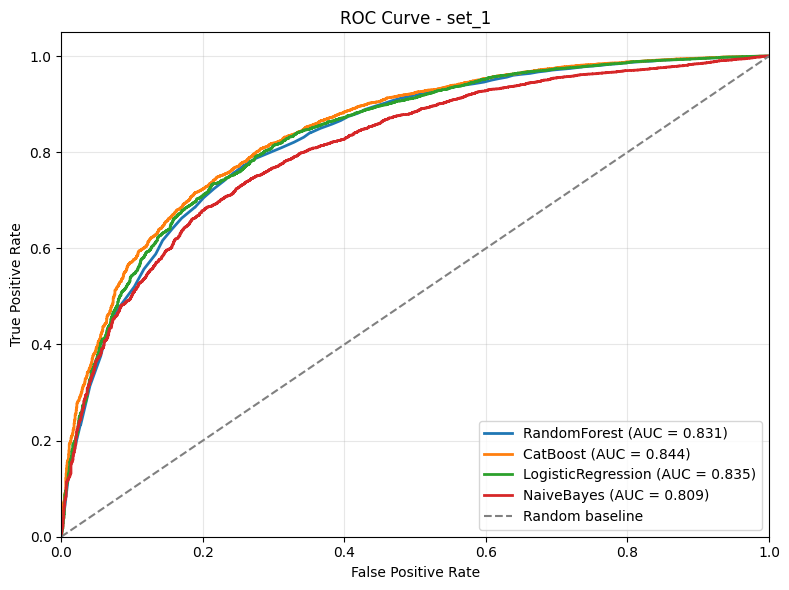

Saved ROC curve for set_1: /content/drive/My Drive/Colab Notebooks/figures/ROC/roc_curve_set_1.png


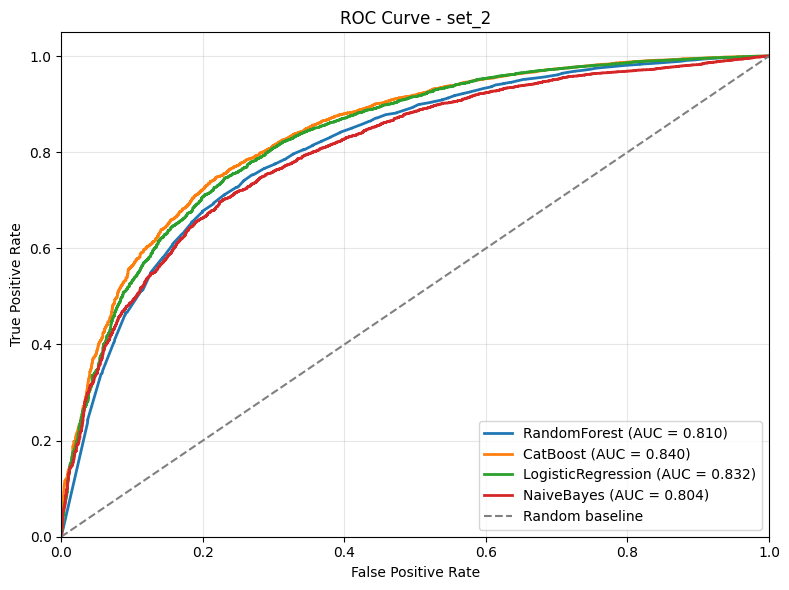

Saved ROC curve for set_2: /content/drive/My Drive/Colab Notebooks/figures/ROC/roc_curve_set_2.png


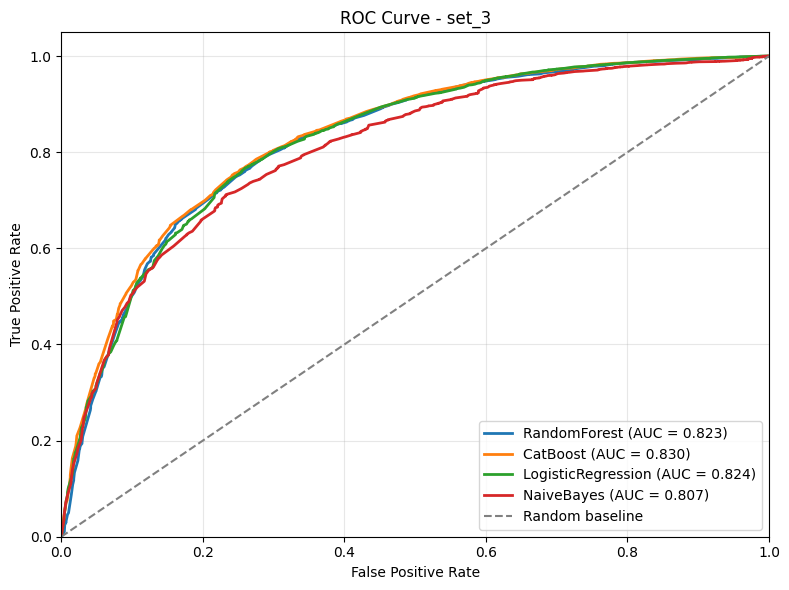

Saved ROC curve for set_3: /content/drive/My Drive/Colab Notebooks/figures/ROC/roc_curve_set_3.png


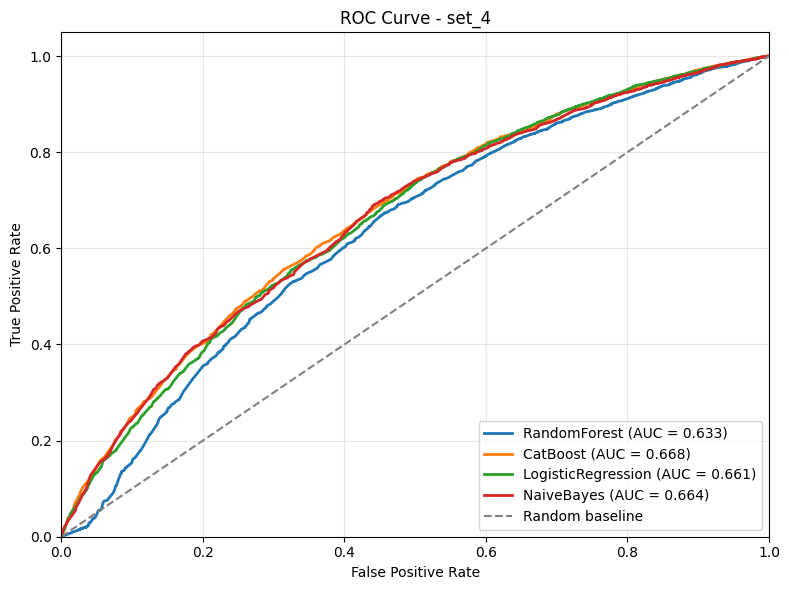

Saved ROC curve for set_4: /content/drive/My Drive/Colab Notebooks/figures/ROC/roc_curve_set_4.png


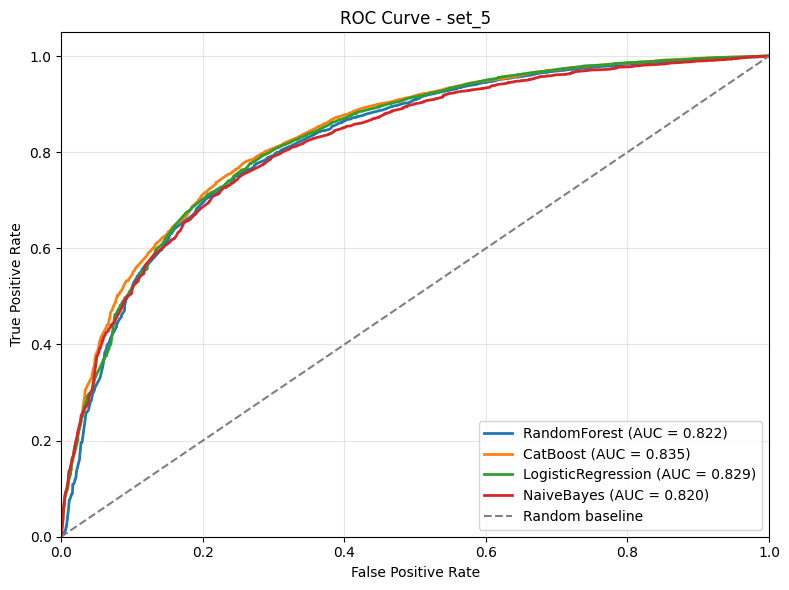

Saved ROC curve for set_5: /content/drive/My Drive/Colab Notebooks/figures/ROC/roc_curve_set_5.png


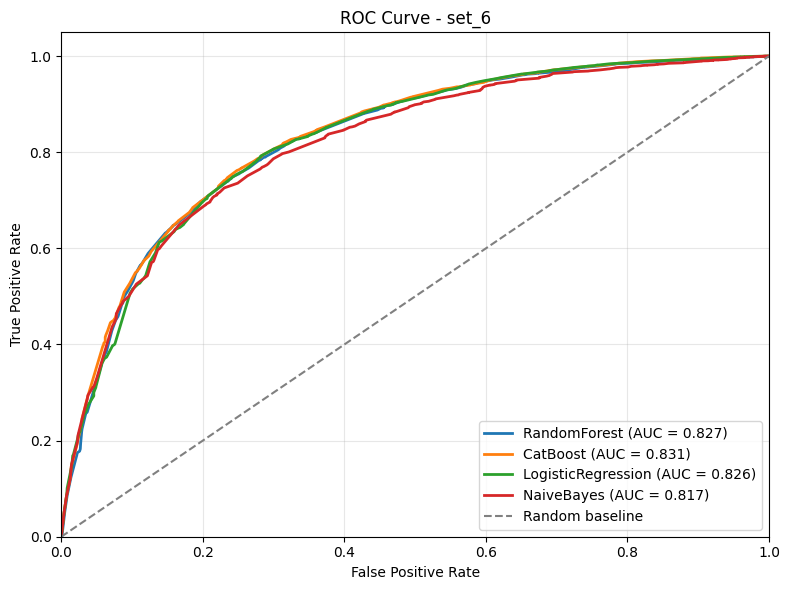

Saved ROC curve for set_6: /content/drive/My Drive/Colab Notebooks/figures/ROC/roc_curve_set_6.png


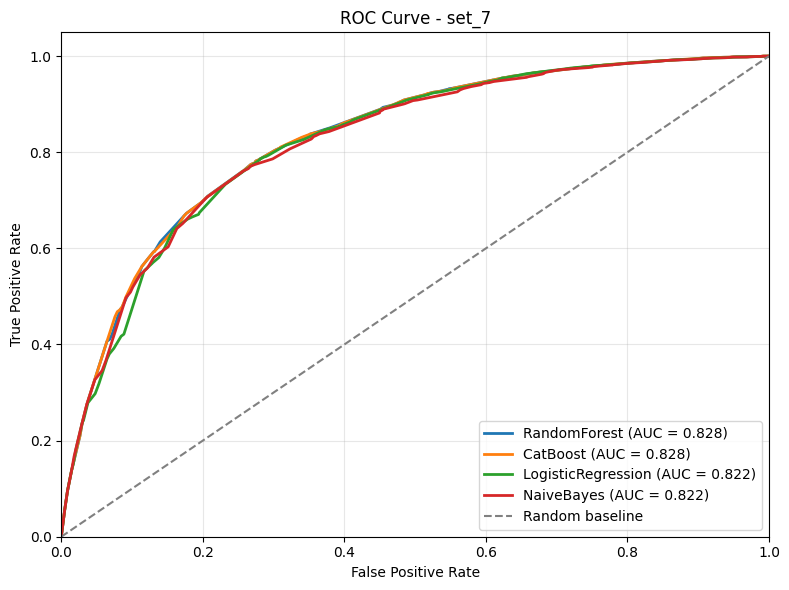

Saved ROC curve for set_7: /content/drive/My Drive/Colab Notebooks/figures/ROC/roc_curve_set_7.png
Saved ROC AUC summary: /content/drive/My Drive/Colab Notebooks/figures/ROC/roc_auc_summary.csv


,feature_set,model,auc
0,set_1,RandomForest,0.830705
1,set_1,CatBoost,0.843793
2,set_1,LogisticRegression,0.835267
3,set_1,NaiveBayes,0.809231
4,set_2,RandomForest,0.810144
5,set_2,CatBoost,0.839646
6,set_2,LogisticRegression,0.832408
7,set_2,NaiveBayes,0.803977
8,set_3,RandomForest,0.823167
9,set_3,CatBoost,0.830429


In [11]:
import os
from sklearn.metrics import roc_curve, auc

ROC_OUTPUT_DIR = "/content/drive/My Drive/Colab Notebooks/figures/ROC"


def _as_1d_array(y):
    if isinstance(y, (pd.DataFrame, pd.Series)):
        return np.ravel(y.values)
    return np.ravel(y)


def _align_features_for_model(model, X):
    if hasattr(model, "feature_names_in_"):
        return X.reindex(columns=model.feature_names_in_, fill_value=0)
    return X


def _get_positive_class_scores(model, X, positive_label=1):
    X_model = _align_features_for_model(model, X)

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_model)
        classes = getattr(model, "classes_", None)

        if probabilities.ndim == 1:
            return probabilities

        if classes is not None and positive_label in classes:
            positive_index = list(classes).index(positive_label)
        else:
            positive_index = probabilities.shape[1] - 1

        return probabilities[:, positive_index]

    if hasattr(model, "decision_function"):
        return model.decision_function(X_model)

    raise AttributeError(f"{type(model).__name__} does not support predict_proba or decision_function.")


def visualise_roc_curves_for_combinations(
    all_models,
    data_splits,
    y_test,
    output_dir=ROC_OUTPUT_DIR,
    positive_label=1
):
    os.makedirs(output_dir, exist_ok=True)
    y_true = _as_1d_array(y_test)
    auc_rows = []

    for combo_name, model_infos in all_models.items():
        X_test_subset = data_splits[combo_name]["X_test"]

        plt.figure(figsize=(8, 6))
        plotted_models = 0

        for model_name, model_info in model_infos.items():
            model = model_info["model"] if isinstance(model_info, dict) and "model" in model_info else model_info

            try:
                y_score = _get_positive_class_scores(model, X_test_subset, positive_label=positive_label)
                fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=positive_label)
                roc_auc = auc(fpr, tpr)
            except Exception as error:
                print(f"Skipping {combo_name} - {model_name}: {error}")
                continue

            plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {roc_auc:.3f})")
            auc_rows.append({
                "feature_set": combo_name,
                "model": model_name,
                "auc": roc_auc
            })
            plotted_models += 1

        if plotted_models == 0:
            plt.close()
            print(f"No ROC curves were plotted for {combo_name}.")
            continue

        plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5, label="Random baseline")
        plt.title(f"ROC Curve - {combo_name}")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.grid(alpha=0.3)
        plt.legend(loc="lower right")
        plt.tight_layout()

        figure_path = os.path.join(output_dir, f"roc_curve_{combo_name}.png")
        plt.savefig(figure_path, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"Saved ROC curve for {combo_name}: {figure_path}")

    auc_df = pd.DataFrame(auc_rows)
    auc_output_path = os.path.join(output_dir, "roc_auc_summary.csv")
    auc_df.to_csv(auc_output_path, index=False)
    print(f"Saved ROC AUC summary: {auc_output_path}")

    return auc_df


roc_auc_summary = visualise_roc_curves_for_combinations(
    all_models=all_models,
    data_splits=data_splits,
    y_test=y_test,
    output_dir=ROC_OUTPUT_DIR,
    positive_label=1
)

roc_auc_summary